# This is a Data Science and Exploration Geochemistry Processing Pipeline for The Luamata South Soil Sampling Campaign Mwinilunga, Zambia

In [2]:
# Install factor analysis modules
! pip install factor_analyzer --quiet

# Install compositional data analysis package
! pip install scikit-bio  --quiet gpxpy pyproj geopandas openpyxl --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 79.8 MB/s eta 0:00:00


In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import warnings
import seaborn as sns

import geopandas as gpd
import gpxpy
import gpxpy.gpx

from pathlib import Path
from pyproj import Transformer
from google.colab import drive, files

import warnings
warnings.filterwarnings("ignore")


warnings.filterwarnings("ignore")
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn import svm
from sklearn.covariance import MinCovDet, EmpiricalCovariance
from sklearn.covariance import MinCovDet
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display, Image

import skbio
import scipy.stats as stats
from skbio.stats.composition import clr
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from tqdm import tqdm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [5]:
print(skbio.__version__)

0.7.3


- The data folder is on my drive, this is important for authentication and maintainability.

In [6]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Loads GPX field waypoints
2. Converts GPS → UTM Zone 35S
3. Loads field logging database
4. Loads:
    • PHASE 1 (200m × 200m)
    • PHASE 2 (100m × 100m infill)
5. Cleans geochemical variables
6. Replaces zeros safely for CoDA
7. Preserves ALL VALID SAMPLES
8. Validates coordinates
9. Merges field + XRF correctly
10. Produces:

    • CLEAN_PHASE1
    • CLEAN_PHASE2
    • COMBINED_MASTER

In [7]:
# THIS IS BASICALLY JUST THE CODE THAT DISPLAYS OUR SETTINGS

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 250)

print("=" * 100)
print("LUAMATA SOIL GEOCHEMISTRY PROJECT")
print("DATA PREPROCESING FOR CoDA AND MULTIVARIATE ANALYSIS PIPELINE")
print("=" * 100)

LUAMATA SOIL GEOCHEMISTRY PROJECT
DATA PREPROCESING FOR CoDA AND MULTIVARIATE ANALYSIS PIPELINE


In [8]:
# GPX WAYPOINTS

GPX_PATH = Path(
    "/content/drive/MyDrive/geochem/FIELD DATA INFILL.gpx"
)

# FIELD LOGGING DATABASE

FIELD_PATH = Path(
    "/content/drive/MyDrive/geochem/FIELD DATA INFILL.xlsx"
)

# PHASE 1 — 200m × 200m

PHASE1_PATH = Path(
    "/content/drive/MyDrive/geochem/merged_field_xrf.xlsx"
)

# PHASE 2 — 100m × 100m INFILL

PHASE2_PATH = Path(
    "/content/drive/MyDrive/geochem/Merged XRF and Field Data.xls"
)

print("✓ File paths defined")

✓ File paths defined


In [9]:
# VALIDATE INPUT FILES

print("\n" + "=" * 100)
print("VALIDATING INPUT FILES")
print("=" * 100)

required_files = {
    "GPX": GPX_PATH,
    "FIELD": FIELD_PATH,
    "PHASE1": PHASE1_PATH,
    "PHASE2": PHASE2_PATH
}

missing_files = []

for name, path in required_files.items():

    if path.exists():

        print(f"✓ {name:<10} FOUND")

    else:

        print(f"✗ {name:<10} MISSING")
        missing_files.append(name)

if len(missing_files) > 0:

    raise FileNotFoundError(
        f"Missing files: {missing_files}"
    )

print("\n✓ All required files located successfully")


VALIDATING INPUT FILES
✓ GPX        FOUND
✓ FIELD      FOUND
✓ PHASE1     FOUND
✓ PHASE2     FOUND

✓ All required files located successfully


In [10]:
# 7. READ GPX WAYPOINTS
# =============================================================================

print("\n" + "=" * 100)
print("READING GPX WAYPOINTS")
print("=" * 100)

with open(GPX_PATH, "r") as f:

    gpx = gpxpy.parse(f)

waypoints = []

for wpt in gpx.waypoints:

    waypoints.append({

        "Sample_ID": str(wpt.name).strip(),

        "Latitude": wpt.latitude,

        "Longitude": wpt.longitude,

        "Elevation_GPS": wpt.elevation,

        "GPS_Time": wpt.time
    })

gpx_df = pd.DataFrame(waypoints)

print(f"✓ GPX waypoints loaded: {len(gpx_df)}")


READING GPX WAYPOINTS
✓ GPX waypoints loaded: 943


In [11]:
# VALIDATE GPS COORDINATES

gpx_df = gpx_df.dropna(
    subset=["Latitude", "Longitude"]
)

In [12]:
# VALID LATITUDE RANGE

gpx_df = gpx_df[
    (gpx_df["Latitude"] >= -90) &
    (gpx_df["Latitude"] <= 90)
]


In [13]:
# VALID LONGITUDE RANGE

gpx_df = gpx_df[
    (gpx_df["Longitude"] >= -180) &
    (gpx_df["Longitude"] <= 180)
]

after = len(gpx_df)

print(f"Invalid GPS records removed : {before - after}")
print(f"Valid GPS records remaining : {after}")

NameError: name 'before' is not defined

In [14]:
# CONVERT GPS → UTM ZONE 35S

# Zambia UTM Zone 35S
# EPSG:32735

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32735",
    always_xy=True
)

eastings = [] # Re-initialize the list
northings = [] # Re-initialize the list

for lon, lat in zip(
    gpx_df["Longitude"],
    gpx_df["Latitude"]
):

    east, north = transformer.transform(
        lon,
        lat
    )

    eastings.append(east)
    northings.append(north)

gpx_df["East_GPX"] = eastings
gpx_df["North_GPX"] = northings

print("✓ GPS converted successfully")

✓ GPS converted successfully


In [15]:
# VALIDATE UTM COORDINATES

print("\n" + "=" * 100)
print("VALIDATING UTM COORDINATES")
print("=" * 100)

utm_valid = (
    (gpx_df["East_GPX"] > 100000) &
    (gpx_df["East_GPX"] < 900000) &
    (gpx_df["North_GPX"] > 7000000) &
    (gpx_df["North_GPX"] < 9000000)
)

invalid_utm = (~utm_valid).sum()

print(f"Invalid UTM coordinates : {invalid_utm}")

gpx_df = gpx_df.loc[utm_valid].copy()

print(f"Remaining valid GPS points : {len(gpx_df)}")


VALIDATING UTM COORDINATES
Invalid UTM coordinates : 0
Remaining valid GPS points : 943


In [16]:
# REMOVE DUPLICATE GPS RECORDS

print("\n" + "=" * 100)
print("REMOVING DUPLICATE GPS RECORDS")
print("=" * 100)

before = len(gpx_df)

gpx_df = gpx_df.drop_duplicates(
    subset="Sample_ID",
    keep="first"
)

after = len(gpx_df)

print(f"Duplicate GPS records removed : {before - after}")
print(f"Remaining GPS records         : {after}")


REMOVING DUPLICATE GPS RECORDS
Duplicate GPS records removed : 1
Remaining GPS records         : 942


In [17]:
# LOAD FIELD DATABASE

print("\n" + "=" * 100)
print("READING FIELD DATABASE")
print("=" * 100)

field_df = pd.read_excel(FIELD_PATH)

print(f"Field records loaded : {len(field_df)}")


READING FIELD DATABASE
Field records loaded : 943


In [18]:
# STANDARDIZE COLUMN NAMES

field_df = field_df.rename(columns={

    "Sample ID": "Sample_ID",
    "East": "East_Field",
    "North": "North_Field"
})

field_df["Sample_ID"] = (
    field_df["Sample_ID"]
    .astype(str)
    .str.strip()
)

field_df = field_df.drop_duplicates(
    subset="Sample_ID",
    keep="first"
)

print(f"Field records after deduplication : {len(field_df)}")

Field records after deduplication : 943


In [19]:
# LOAD PHASE 1 AND PHASE 2

print("\n" + "=" * 100)
print("LOADING PHASE DATASETS")
print("=" * 100)

phase1 = pd.read_excel(PHASE1_PATH)
phase2 = pd.read_excel(PHASE2_PATH)

print(f"Phase 1 loaded : {len(phase1)} samples")
print(f"Phase 2 loaded : {len(phase2)} samples")


LOADING PHASE DATASETS
Phase 1 loaded : 781 samples
Phase 2 loaded : 973 samples


In [20]:
# STANDARDIZE SAMPLE IDS

print("\n" + "=" * 100)
print("STANDARDIZING SAMPLE IDS")
print("=" * 100)

def standardize_ids(df):

    rename_map = {
        "Sample ID": "Sample_ID",
        "SpecName": "Sample_ID"
    }

    df = df.rename(columns=rename_map)

    df["Sample_ID"] = (
        df["Sample_ID"]
        .astype(str)
        .str.strip()
    )

    return df


phase1 = standardize_ids(phase1)
phase2 = standardize_ids(phase2)

print("✓ Sample IDs standardized")


STANDARDIZING SAMPLE IDS
✓ Sample IDs standardized


In [21]:
# REMOVE QAQC / AMIS SAMPLES

print("\n" + "=" * 100)
print("REMOVING QAQC / AMIS SAMPLES")
print("=" * 100)

def remove_qaqc(df, name):

    before = len(df)

    mask = (
        df["Sample_ID"]
        .astype(str)
        .str.contains(
            "AMIS|STD|STANDARD|BLANK",
            case=False,
            na=False
        )
    )

    df = df.loc[~mask].copy()

    removed = before - len(df)

    print(f"{name:<10} QAQC removed : {removed}")

    return df


phase1 = remove_qaqc(phase1, "PHASE1")
phase2 = remove_qaqc(phase2, "PHASE2")


REMOVING QAQC / AMIS SAMPLES
PHASE1     QAQC removed : 0
PHASE2     QAQC removed : 0


In [22]:
# REMOVE TRUE DUPLICATES

print("\n" + "=" * 100)
print("REMOVING TRUE DUPLICATES")
print("=" * 100)

def remove_duplicates(df, name):

    before = len(df)

    df = df.drop_duplicates(
        subset="Sample_ID",
        keep="first"
    )

    removed = before - len(df)

    print(f"{name:<10} duplicates removed : {removed}")

    return df


phase1 = remove_duplicates(phase1, "PHASE1")
phase2 = remove_duplicates(phase2, "PHASE2")


REMOVING TRUE DUPLICATES
PHASE1     duplicates removed : 2
PHASE2     duplicates removed : 0


In [23]:
# DETECT GEOCHEMICAL VARIABLES

print("\n" + "=" * 100)
print("DETECTING GEOCHEMICAL VARIABLES")
print("=" * 100)

def detect_geochem(df):

    cols = []

    for c in df.columns:

        if "(PPM)" in str(c).upper():

            cols.append(c)

    return cols


geo1 = detect_geochem(phase1)
geo2 = detect_geochem(phase2)

print(f"Phase 1 geochemical variables : {len(geo1)}")
print(f"Phase 2 geochemical variables : {len(geo2)}")


DETECTING GEOCHEMICAL VARIABLES
Phase 1 geochemical variables : 24
Phase 2 geochemical variables : 28


In [24]:
# CONVERT GEOCHEMISTRY TO NUMERIC

print("\n" + "=" * 100)
print("CONVERTING GEOCHEMISTRY TO NUMERIC")
print("=" * 100)

def convert_numeric(df, cols):

    for col in cols:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df


phase1 = convert_numeric(phase1, geo1)
phase2 = convert_numeric(phase2, geo2)

print("✓ Numeric conversion completed")


CONVERTING GEOCHEMISTRY TO NUMERIC
✓ Numeric conversion completed


In [25]:
# ZERO REPLACEMENT FOR CoDA

# IMPORTANT:
#
# WE DO NOT DROP SAMPLES
# WE ONLY REPLACE ZEROS

def replace_zeros(df, geochem_cols, dataset_name):

    print(f"\nProcessing {dataset_name}")

    summary = []

    for col in geochem_cols:

        values = df[col].copy()

        positive = values[values > 0]

        if len(positive) == 0:

            print(f"Skipping {col:<20} (all zeros)")
            continue

        replacement_value = positive.min() / 2

        zero_count = (values == 0).sum()

        df.loc[df[col] == 0, col] = replacement_value

        summary.append({
            "Variable": col,
            "Zeros_Replaced": zero_count,
            "Replacement_Value": replacement_value
        })

    summary_df = pd.DataFrame(summary)

    print(f"✓ {dataset_name} zero replacement completed")

    return df, summary_df


phase1, phase1_zero_summary = replace_zeros(
    phase1,
    geo1,
    "PHASE 1"
)

phase2, phase2_zero_summary = replace_zeros(
    phase2,
    geo2,
    "PHASE 2"
)


Processing PHASE 1
Skipping Hg(PPM)              (all zeros)
✓ PHASE 1 zero replacement completed

Processing PHASE 2
Skipping P(PPM)               (all zeros)
Skipping S(PPM)               (all zeros)
✓ PHASE 2 zero replacement completed


In [26]:
# MERGE GPX + FIELD DATABASE

print("\n" + "=" * 100)
print("MERGING GPS + FIELD DATABASE")
print("=" * 100)

field_merged = pd.merge(

    gpx_df,
    field_df,

    on="Sample_ID",
    how="left"
)

print(f"Merged field records : {len(field_merged)}")


MERGING GPS + FIELD DATABASE
Merged field records : 942


In [27]:
# COORDINATE VALIDATION

print("\n" + "=" * 100)
print("VALIDATING FIELD COORDINATES")
print("=" * 100)

if (
    "East_Field" in field_merged.columns and
    "North_Field" in field_merged.columns
):

    field_merged["East_diff"] = np.abs(
        field_merged["East_GPX"] -
        field_merged["East_Field"]
    )

    field_merged["North_diff"] = np.abs(
        field_merged["North_GPX"] -
        field_merged["North_Field"]
    )

    mismatch = (
        (field_merged["East_diff"] > 10) |
        (field_merged["North_diff"] > 10)
    )

    print(f"Coordinate mismatches >10 m : {mismatch.sum()}")

else:

    print("No field coordinate columns found")


VALIDATING FIELD COORDINATES
Coordinate mismatches >10 m : 56


In [28]:
print("\nUsing GPX coordinates as authoritative coordinates")

field_merged["East"] = field_merged["East_GPX"]
field_merged["North"] = field_merged["North_GPX"]


Using GPX coordinates as authoritative coordinates


In [29]:
# MERGE PHASE 2 FIELD + XRF

print("\n" + "=" * 100)
print("MERGING PHASE 2 FIELD + XRF")
print("=" * 100)

phase2_merged = pd.merge(
    field_merged,
    phase2,
    on="Sample_ID",
    how="inner"
)

print(f"Phase 2 merged samples : {len(phase2_merged)}")



MERGING PHASE 2 FIELD + XRF
Phase 2 merged samples : 940


In [30]:
# DEFINE FINAL ANALYTICAL STRUCTURE

print("\n" + "=" * 100)
print("DEFINING FINAL ANALYTICAL STRUCTURE")
print("=" * 100)

FINAL_COLUMNS = [

    "Sample_ID",
    "East",
    "North",

    "K(PPM)",
    "Ca(PPM)",
    "Ti(PPM)",
    "V(PPM)",
    "Cr(PPM)",
    "Mn(PPM)",
    "Fe(PPM)",
    "Co(PPM)",
    "Ni(PPM)",
    "Cu(PPM)",
    "Zn(PPM)",
    "Ga(PPM)",
    "As(PPM)",
    "Rb(PPM)",
    "Sr(PPM)",
    "Y(PPM)",
    "Zr(PPM)",
    "Nb(PPM)",
    "Mo(PPM)",
    "Ag(PPM)",
    "Sn(PPM)",
    "Sb(PPM)",
    "Pb(PPM)"
]

GEOCHEM_COLS = FINAL_COLUMNS[3:]


DEFINING FINAL ANALYTICAL STRUCTURE


In [32]:
# PREPARE PHASE 1

print("\nPreparing Phase 1")

# Create East column if missing
if "East" not in phase1.columns:
    if "East_GPX" in phase1.columns:
        phase1["East"] = phase1["East_GPX"]

# Create North column if missing
if "North" not in phase1.columns:
    if "North_GPX" in phase1.columns:
        phase1["North"] = phase1["North_GPX"]

# Ensure all required columns exist
for col in FINAL_COLUMNS:
    if col not in phase1.columns:
        phase1[col] = np.nan

# Reorder columns
CLEAN_PHASE1 = phase1[FINAL_COLUMNS].copy()

print(f"Phase 1 prepared: {len(CLEAN_PHASE1):,} records")
print(f"Columns: {len(CLEAN_PHASE1.columns)}")


Preparing Phase 1
Phase 1 prepared: 779 records
Columns: 26


In [33]:
# PREPARE PHASE 2

print("Preparing Phase 2")

for col in FINAL_COLUMNS:

    if col not in phase2_merged.columns:
        phase2_merged[col] = np.nan

CLEAN_PHASE2 = phase2_merged[FINAL_COLUMNS].copy()

Preparing Phase 2


In [34]:
print("\nConverting geochemistry to numeric")

for dataset in [CLEAN_PHASE1, CLEAN_PHASE2]:

    for col in GEOCHEM_COLS:

        dataset[col] = pd.to_numeric(
            dataset[col],
            errors="coerce"
        )


Converting geochemistry to numeric


In [35]:
print("\nApplying final zero replacement")

def final_zero_replacement(df):

    df = df.copy()

    for col in GEOCHEM_COLS:

        positive = df.loc[df[col] > 0, col]

        if len(positive) == 0:
            continue

        replacement = positive.min() / 2

        df.loc[df[col] == 0, col] = replacement

    return df


CLEAN_PHASE1 = final_zero_replacement(CLEAN_PHASE1)
CLEAN_PHASE2 = final_zero_replacement(CLEAN_PHASE2)


Applying final zero replacement


In [36]:
print("\n" + "=" * 100)
print("VALIDATING COORDINATES")
print("=" * 100)

def validate_coordinates(df, name):

    valid = (
        (df["East"] > 100000) &
        (df["East"] < 900000) &
        (df["North"] > 7000000) &
        (df["North"] < 9000000)
    )

    print(
        f"{name:<15}"
        f" Valid = {valid.sum():<6}"
        f" Invalid = {(~valid).sum():<6}"
    )

validate_coordinates(
    CLEAN_PHASE1,
    "PHASE 1"
)

validate_coordinates(
    CLEAN_PHASE2,
    "PHASE 2"
)


VALIDATING COORDINATES
PHASE 1         Valid = 778    Invalid = 1     
PHASE 2         Valid = 940    Invalid = 0     


In [38]:
# BUILD COMBINED MASTER

print("\n" + "=" * 100)
print("BUILDING COMBINED MASTER")
print("=" * 100)

COMBINED_MASTER = pd.concat(
    [
        CLEAN_PHASE1,
        CLEAN_PHASE2
    ],
    ignore_index=True
)

COMBINED_MASTER = COMBINED_MASTER.drop_duplicates(
    subset="Sample_ID",
    keep="first"
)

print(f"Combined samples : {len(COMBINED_MASTER)}")


BUILDING COMBINED MASTER
Combined samples : 1719


In [39]:
CLEAN_PHASE1 = CLEAN_PHASE1[FINAL_COLUMNS]
CLEAN_PHASE2 = CLEAN_PHASE2[FINAL_COLUMNS]
COMBINED_MASTER = COMBINED_MASTER[FINAL_COLUMNS]

In [40]:
print("\n" + "=" * 100)
print("EXPORTING DATASETS")
print("=" * 100)

phase1_output = "/content/CLEAN_PHASE1_200m.xlsx"
phase2_output = "/content/CLEAN_PHASE2_100m.xlsx"
combined_output = "/content/LUAMATA_COMBINED_MASTER.xlsx"

CLEAN_PHASE1.to_excel(
    phase1_output,
    index=False
)

CLEAN_PHASE2.to_excel(
    phase2_output,
    index=False
)

COMBINED_MASTER.to_excel(
    combined_output,
    index=False
)

print("✓ Export complete")


EXPORTING DATASETS
✓ Export complete


In [41]:
files.download(phase1_output)
files.download(phase2_output)
files.download(combined_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
print("\n" + "=" * 100)
print("FINAL QAQC SUMMARY")
print("=" * 100)

print(f"PHASE 1 : {len(CLEAN_PHASE1)} samples")
print(f"PHASE 2 : {len(CLEAN_PHASE2)} samples")
print(f"COMBINED: {len(COMBINED_MASTER)} samples")

print("\nFinal variables:")

for col in COMBINED_MASTER.columns:
    print(col)

print("\nMissing values")

display(
    COMBINED_MASTER.isna().sum().to_frame(
        "Missing"
    )
)


FINAL QAQC SUMMARY
PHASE 1 : 779 samples
PHASE 2 : 940 samples
COMBINED: 1719 samples

Final variables:
Sample_ID
East
North
K(PPM)
Ca(PPM)
Ti(PPM)
V(PPM)
Cr(PPM)
Mn(PPM)
Fe(PPM)
Co(PPM)
Ni(PPM)
Cu(PPM)
Zn(PPM)
Ga(PPM)
As(PPM)
Rb(PPM)
Sr(PPM)
Y(PPM)
Zr(PPM)
Nb(PPM)
Mo(PPM)
Ag(PPM)
Sn(PPM)
Sb(PPM)
Pb(PPM)

Missing values


,Missing
Sample_ID,0
East,0
North,0
K(PPM),0
Ca(PPM),0
Ti(PPM),0
V(PPM),0
Cr(PPM),0
Mn(PPM),0
Fe(PPM),0


In [43]:
print("\nPHASE 1")
display(CLEAN_PHASE1.head())


PHASE 1


,Sample_ID,East,North,K(PPM),Ca(PPM),Ti(PPM),V(PPM),Cr(PPM),Mn(PPM),Fe(PPM),Co(PPM),Ni(PPM),Cu(PPM),Zn(PPM),Ga(PPM),As(PPM),Rb(PPM),Sr(PPM),Y(PPM),Zr(PPM),Nb(PPM),Mo(PPM),Ag(PPM),Sn(PPM),Sb(PPM),Pb(PPM)
0,V08001,227170.943879,8.678390e+06,8088.939941,2.265995,5938.450195,77.529999,68.970200,228.037994,31962.300781,0.018435,15.765800,109.353996,11.168000,15.286400,3.84024,72.487999,20.862499,21.484600,220.921005,20.397100,1.803190,0.087191,10.521700,57.700500,6.85470
1,V08002,227159.097800,8.678615e+06,7434.000000,2.265995,5823.310059,137.251999,78.311996,472.260010,51871.101562,0.018435,53.127102,260.975006,9.399260,20.153799,4.98783,72.608002,26.761499,22.041700,258.618011,25.600401,4.336480,0.087191,18.000000,12.509700,7.08469
2,V08003,227171.028204,8.678790e+06,7027.299805,69.075104,5858.609863,106.641998,92.697098,518.232971,49496.398438,0.018435,33.306599,252.371002,25.056200,17.053699,6.06224,63.812801,32.755001,20.264700,254.975006,24.516701,0.133981,0.087191,12.524900,22.302500,5.68593
3,V08004,227170.852850,8.678990e+06,2761.639893,2.265995,5101.779785,91.196999,72.055702,435.368011,43918.800781,0.018435,44.573601,137.018005,32.636799,15.406300,7.25797,43.297199,15.795600,20.864100,330.039001,27.229401,6.424270,16.567801,16.025600,0.175574,3.10880
4,V08005,227170.791775,8.679190e+06,4294.620117,2.265995,6976.370117,113.897003,84.497803,690.693970,68325.203125,0.018435,58.440399,120.776001,39.133900,17.080700,8.69838,30.650200,19.925800,21.108601,332.843994,27.285000,0.241289,0.087191,16.425699,0.175574,13.50970


In [44]:
print("\nPHASE 2")
display(CLEAN_PHASE2.head())


PHASE 2


,Sample_ID,East,North,K(PPM),Ca(PPM),Ti(PPM),V(PPM),Cr(PPM),Mn(PPM),Fe(PPM),Co(PPM),Ni(PPM),Cu(PPM),Zn(PPM),Ga(PPM),As(PPM),Rb(PPM),Sr(PPM),Y(PPM),Zr(PPM),Nb(PPM),Mo(PPM),Ag(PPM),Sn(PPM),Sb(PPM),Pb(PPM)
0,O00301,225858.293315,8.678212e+06,9311.410156,11.45535,5710.930176,98.459900,71.774200,659.372009,57703.800781,0.204338,7.933450,117.617996,41.860401,14.929500,6.83912,116.908997,29.058399,23.767799,234.503006,25.215200,3.14541,0.113349,18.00000,160.979996,8.54607
1,O00302,225857.454031,8.678113e+06,9612.179688,11.45535,5899.740234,95.242699,66.913498,562.129028,52294.800781,0.204338,11.258500,124.260002,42.010700,17.057301,7.18483,107.779999,24.829700,23.899799,239.477005,24.590099,15.00810,0.113349,2.50192,66.130997,8.85673
2,O00303,225852.468865,8.678026e+06,10579.599609,11.45535,5923.899902,144.348007,71.070602,697.151978,64249.898438,0.204338,0.002667,150.996994,56.026402,19.229401,6.89133,147.483994,43.317001,24.053900,252.434998,25.999300,1.59885,0.113349,5.34940,0.179372,12.64890
3,O00304,225858.410275,8.677912e+06,8017.180176,11.45535,6612.950195,92.195396,71.572998,371.045990,49982.101562,0.204338,0.002667,140.783997,12.577600,14.179500,3.09979,97.720398,27.217100,24.182301,252.279007,32.085201,1.00176,0.113349,12.37310,0.179372,2.89250
4,O00305,225858.558049,8.677812e+06,16139.500000,11.45535,7311.939941,121.568001,86.324898,268.886993,68511.000000,0.204338,12.733900,172.141998,3.907940,18.871099,0.52589,115.903000,40.589199,22.667999,251.906006,27.778099,5.71180,0.113349,18.00000,52.374298,2.05168


In [45]:
print("\nCOMBINED")
display(COMBINED_MASTER.head())


COMBINED


,Sample_ID,East,North,K(PPM),Ca(PPM),Ti(PPM),V(PPM),Cr(PPM),Mn(PPM),Fe(PPM),Co(PPM),Ni(PPM),Cu(PPM),Zn(PPM),Ga(PPM),As(PPM),Rb(PPM),Sr(PPM),Y(PPM),Zr(PPM),Nb(PPM),Mo(PPM),Ag(PPM),Sn(PPM),Sb(PPM),Pb(PPM)
0,V08001,227170.943879,8.678390e+06,8088.939941,2.265995,5938.450195,77.529999,68.970200,228.037994,31962.300781,0.018435,15.765800,109.353996,11.168000,15.286400,3.84024,72.487999,20.862499,21.484600,220.921005,20.397100,1.803190,0.087191,10.521700,57.700500,6.85470
1,V08002,227159.097800,8.678615e+06,7434.000000,2.265995,5823.310059,137.251999,78.311996,472.260010,51871.101562,0.018435,53.127102,260.975006,9.399260,20.153799,4.98783,72.608002,26.761499,22.041700,258.618011,25.600401,4.336480,0.087191,18.000000,12.509700,7.08469
2,V08003,227171.028204,8.678790e+06,7027.299805,69.075104,5858.609863,106.641998,92.697098,518.232971,49496.398438,0.018435,33.306599,252.371002,25.056200,17.053699,6.06224,63.812801,32.755001,20.264700,254.975006,24.516701,0.133981,0.087191,12.524900,22.302500,5.68593
3,V08004,227170.852850,8.678990e+06,2761.639893,2.265995,5101.779785,91.196999,72.055702,435.368011,43918.800781,0.018435,44.573601,137.018005,32.636799,15.406300,7.25797,43.297199,15.795600,20.864100,330.039001,27.229401,6.424270,16.567801,16.025600,0.175574,3.10880
4,V08005,227170.791775,8.679190e+06,4294.620117,2.265995,6976.370117,113.897003,84.497803,690.693970,68325.203125,0.018435,58.440399,120.776001,39.133900,17.080700,8.69838,30.650200,19.925800,21.108601,332.843994,27.285000,0.241289,0.087191,16.425699,0.175574,13.50970


Phase 1 samples after cleaning: 758
Total samples: 758
Outliers: 262 (34.6%)


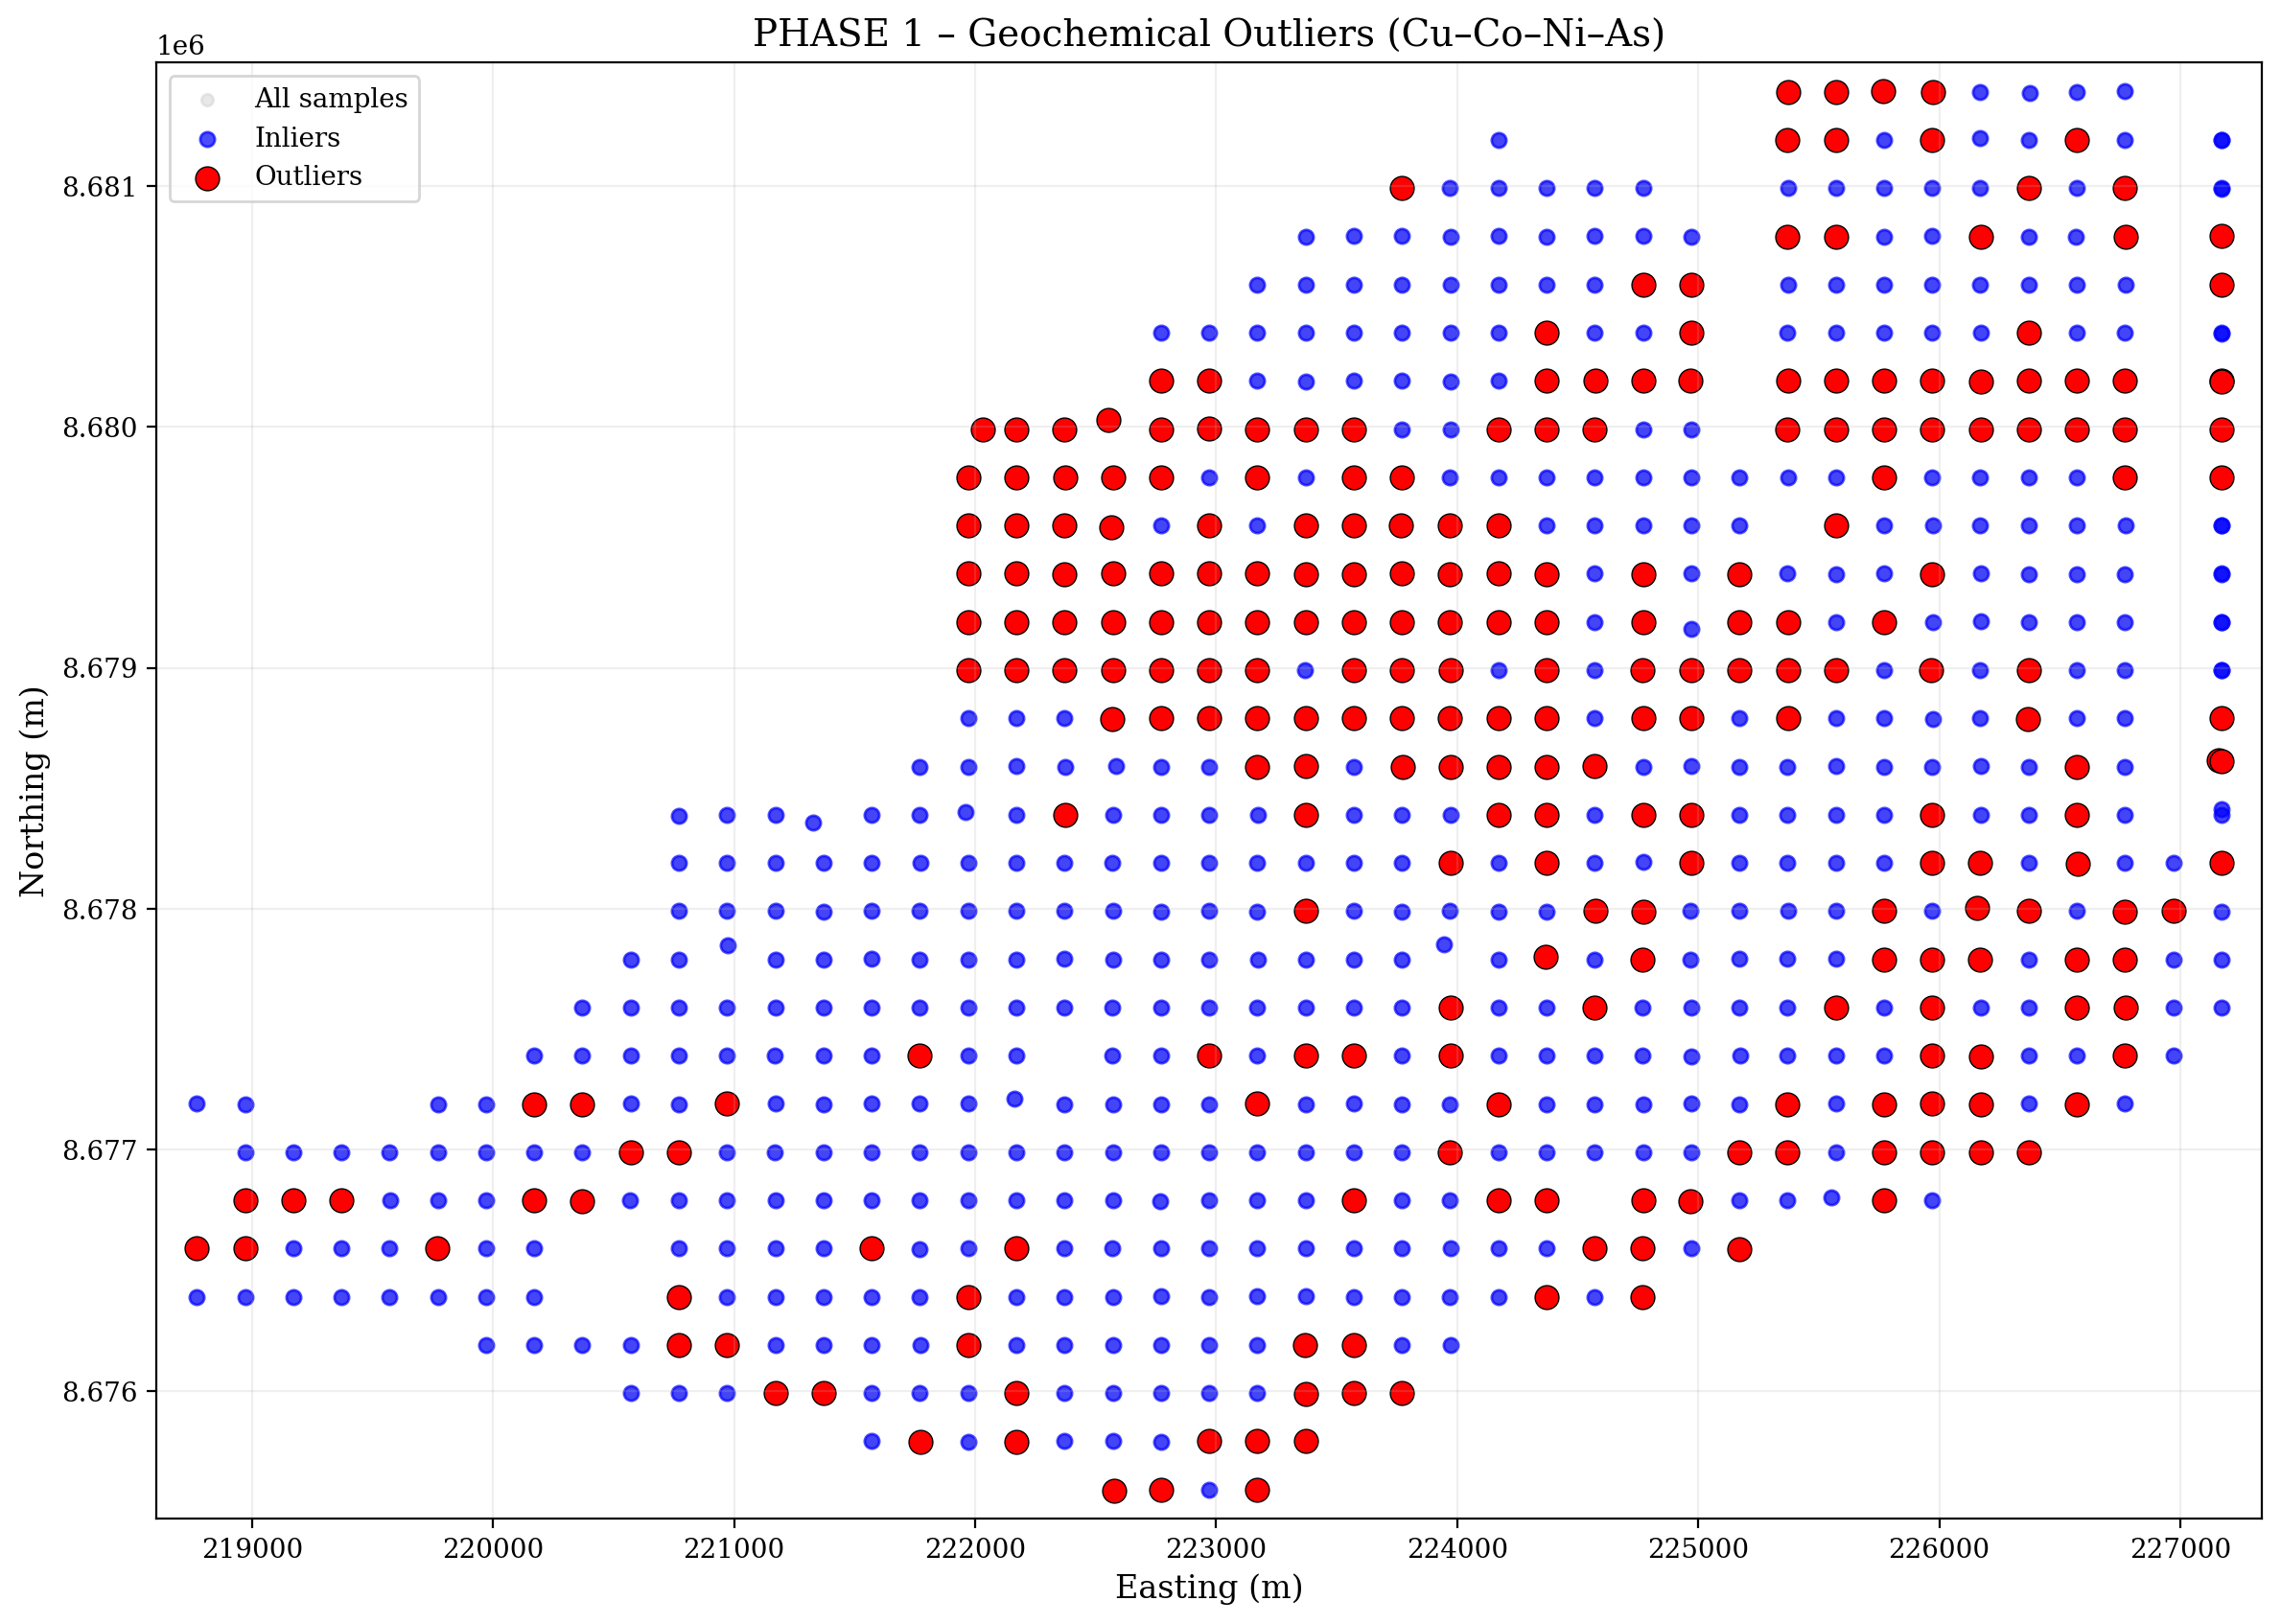

In [47]:
# =============================================================================
# PHASE 1 – GEOCHEMICAL OUTLIER MAP (Cu, Co, Ni, As)
# Using the same robust workflow as your single‑plot script
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skbio.stats.composition import clr
from sklearn.covariance import MinCovDet
import scipy.stats as stats

# -----------------------------------------------------------------
# 1. Use your existing Phase 1 cleaned dataframe
# -----------------------------------------------------------------
df = CLEAN_PHASE1.copy()

# Ensure coordinates are named 'x' and 'y' for plotting (original has 'East', 'North')
df.rename(columns={'East': 'x', 'North': 'y'}, inplace=True)

# Remove rows with missing coordinates (safety)
df = df.dropna(subset=['x', 'y'])

# Optional: filter to study area (same limits as your working code)
df = df[(df['x'] > 150000) & (df['x'] < 350000) &
        (df['y'] > 8500000) & (df['y'] < 8800000)]

# Remove duplicates (by Sample_ID if exists, else by coordinates)
if 'Sample_ID' in df.columns:
    df = df.drop_duplicates(subset='Sample_ID', keep='first')
df = df.drop_duplicates(subset=['x', 'y'], keep='first')

# -----------------------------------------------------------------
# 2. Define pathfinder elements (Cu, Co, Ni, As)
# -----------------------------------------------------------------
pathfinder = ['Cu(PPM)', 'Co(PPM)', 'Ni(PPM)', 'As(PPM)']
# Keep only those present
pathfinder = [c for c in pathfinder if c in df.columns]
df = df.dropna(subset=pathfinder)

print(f"Phase 1 samples after cleaning: {len(df)}")

# -----------------------------------------------------------------
# 3. Zero replacement (multiplicative, exactly as in your working code)
# -----------------------------------------------------------------
def mult_replace(series, delta_factor=2/3):
    vals = series.values.astype(float).copy()
    pos = vals[vals > 0]
    if len(pos) == 0:
        raise ValueError(f"{series.name} contains only zeros")
    delta = pos.min() * delta_factor
    zeros = vals == 0
    if zeros.sum() == 0:
        return vals
    total_nonzero = vals[~zeros].sum()
    scale = (total_nonzero + zeros.sum() * delta) / total_nonzero
    vals[~zeros] *= scale
    vals[zeros] = delta
    return vals

comp_data = df[pathfinder].apply(mult_replace)

# -----------------------------------------------------------------
# 4. CLR transformation
# -----------------------------------------------------------------
clr_matrix = clr(comp_data.values + 1e-6)
clr_df = pd.DataFrame(clr_matrix, columns=[f'clr({c})' for c in pathfinder])

# -----------------------------------------------------------------
# 5. Robust Mahalanobis distance
# -----------------------------------------------------------------
X = clr_df.values
robust_cov = MinCovDet().fit(X)
rmd = np.sqrt(robust_cov.mahalanobis(X))
dof = X.shape[1]
threshold = np.sqrt(stats.chi2.ppf(0.95, df=dof))
outliers = rmd > threshold

df['RMD'] = rmd
df['Outlier'] = outliers

print(f"Total samples: {len(df)}")
print(f"Outliers: {outliers.sum()} ({outliers.sum()/len(df)*100:.1f}%)")

# -----------------------------------------------------------------
# 6. Spatial plot (same style as your working script)
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# All samples (light grey)
ax.scatter(df['x'], df['y'], c='lightgray', s=20, alpha=0.5, label='All samples')

# Inliers (blue)
ax.scatter(df.loc[~df['Outlier'], 'x'], df.loc[~df['Outlier'], 'y'],
           c='blue', s=30, alpha=0.7, label='Inliers')

# Outliers (red, larger)
ax.scatter(df.loc[df['Outlier'], 'x'], df.loc[df['Outlier'], 'y'],
           c='red', s=80, edgecolor='black', linewidth=0.5, label='Outliers')

# Map limits
x_min, x_max = df['x'].min(), df['x'].max()
y_min, y_max = df['y'].min(), df['y'].max()
margin_x = (x_max - x_min) * 0.02 if x_max != x_min else 1
margin_y = (y_max - y_min) * 0.02 if y_max != y_min else 1
ax.set_xlim(x_min - margin_x, x_max + margin_x)
ax.set_ylim(y_min - margin_y, y_max + margin_y)

ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title('PHASE 1 – Geochemical Outliers (Cu–Co–Ni–As)', fontsize=14)
ax.legend()
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Phase 2 samples after cleaning: 940
Total samples: 940
Outliers: 467 (49.7%)


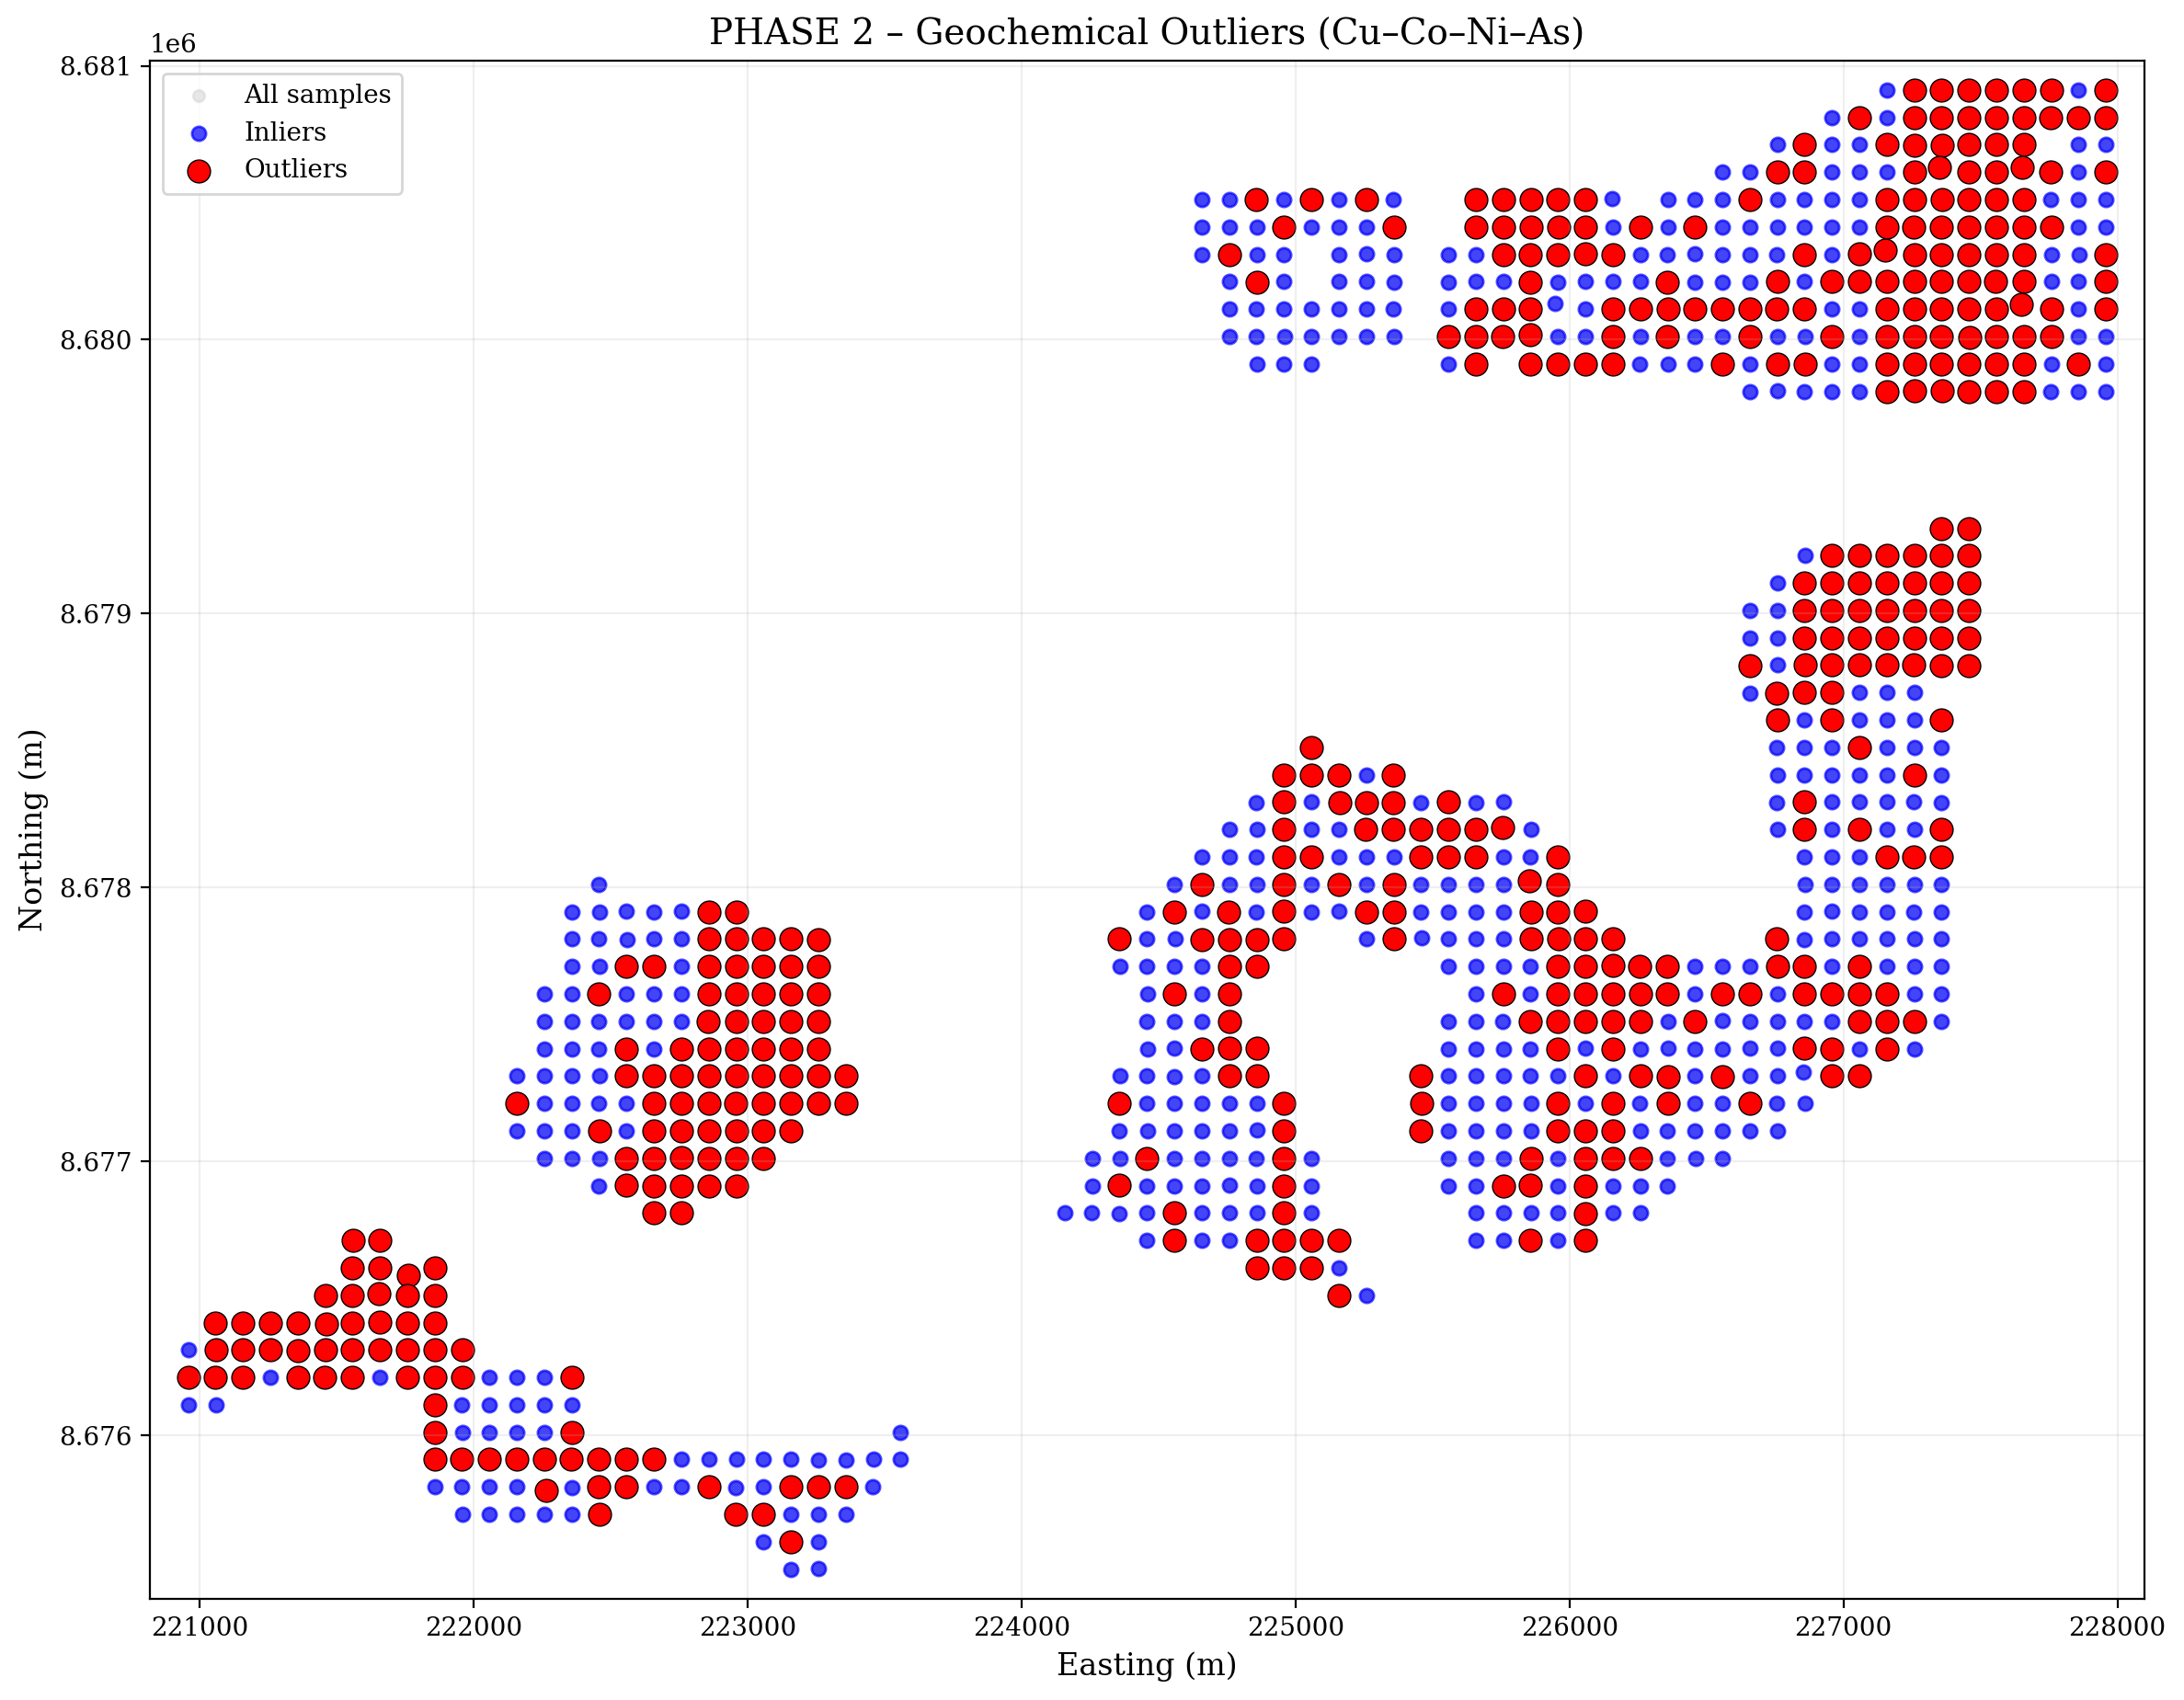

In [48]:
# =============================================================================
# PHASE 2 – GEOCHEMICAL OUTLIER MAP (Cu, Co, Ni, As)
# Using the same robust workflow as your single‑plot script
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skbio.stats.composition import clr
from sklearn.covariance import MinCovDet
import scipy.stats as stats

# -----------------------------------------------------------------
# 1. Use your existing Phase 2 cleaned dataframe
# -----------------------------------------------------------------
df = CLEAN_PHASE2.copy()

# Rename coordinates for plotting (original: 'East', 'North')
df.rename(columns={'East': 'x', 'North': 'y'}, inplace=True)

# Remove rows with missing coordinates (safety)
df = df.dropna(subset=['x', 'y'])

# Optional: filter to study area (same limits as your working code)
df = df[(df['x'] > 150000) & (df['x'] < 350000) &
        (df['y'] > 8500000) & (df['y'] < 8800000)]

# Remove duplicates (by Sample_ID if exists, else by coordinates)
if 'Sample_ID' in df.columns:
    df = df.drop_duplicates(subset='Sample_ID', keep='first')
df = df.drop_duplicates(subset=['x', 'y'], keep='first')

# -----------------------------------------------------------------
# 2. Define pathfinder elements (Cu, Co, Ni, As)
# -----------------------------------------------------------------
pathfinder = ['Cu(PPM)', 'Co(PPM)', 'Ni(PPM)', 'As(PPM)']
# Keep only those present in the dataframe
pathfinder = [c for c in pathfinder if c in df.columns]
df = df.dropna(subset=pathfinder)

print(f"Phase 2 samples after cleaning: {len(df)}")

# -----------------------------------------------------------------
# 3. Zero replacement (multiplicative, exactly as in your working code)
# -----------------------------------------------------------------
def mult_replace(series, delta_factor=2/3):
    vals = series.values.astype(float).copy()
    pos = vals[vals > 0]
    if len(pos) == 0:
        raise ValueError(f"{series.name} contains only zeros")
    delta = pos.min() * delta_factor
    zeros = vals == 0
    if zeros.sum() == 0:
        return vals
    total_nonzero = vals[~zeros].sum()
    scale = (total_nonzero + zeros.sum() * delta) / total_nonzero
    vals[~zeros] *= scale
    vals[zeros] = delta
    return vals

comp_data = df[pathfinder].apply(mult_replace)

# -----------------------------------------------------------------
# 4. CLR transformation
# -----------------------------------------------------------------
clr_matrix = clr(comp_data.values + 1e-6)
clr_df = pd.DataFrame(clr_matrix, columns=[f'clr({c})' for c in pathfinder])

# -----------------------------------------------------------------
# 5. Robust Mahalanobis distance
# -----------------------------------------------------------------
X = clr_df.values
robust_cov = MinCovDet().fit(X)
rmd = np.sqrt(robust_cov.mahalanobis(X))
dof = X.shape[1]
threshold = np.sqrt(stats.chi2.ppf(0.95, df=dof))
outliers = rmd > threshold

df['RMD'] = rmd
df['Outlier'] = outliers

print(f"Total samples: {len(df)}")
print(f"Outliers: {outliers.sum()} ({outliers.sum()/len(df)*100:.1f}%)")

# -----------------------------------------------------------------
# 6. Spatial plot (same style as your working script)
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# All samples (light grey)
ax.scatter(df['x'], df['y'], c='lightgray', s=20, alpha=0.5, label='All samples')

# Inliers (blue)
ax.scatter(df.loc[~df['Outlier'], 'x'], df.loc[~df['Outlier'], 'y'],
           c='blue', s=30, alpha=0.7, label='Inliers')

# Outliers (red, larger)
ax.scatter(df.loc[df['Outlier'], 'x'], df.loc[df['Outlier'], 'y'],
           c='red', s=80, edgecolor='black', linewidth=0.5, label='Outliers')

# Map limits
x_min, x_max = df['x'].min(), df['x'].max()
y_min, y_max = df['y'].min(), df['y'].max()
margin_x = (x_max - x_min) * 0.02 if x_max != x_min else 1
margin_y = (y_max - y_min) * 0.02 if y_max != y_min else 1
ax.set_xlim(x_min - margin_x, x_max + margin_x)
ax.set_ylim(y_min - margin_y, y_max + margin_y)

ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_title('PHASE 2 – Geochemical Outliers (Cu–Co–Ni–As)', fontsize=14)
ax.legend()
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Original samples: 1,719
Using coordinates: East , North
Samples after coordinate cleaning: 1,718
Samples after duplicate removal: 1,698
Elements used:
['Cu(PPM)', 'Co(PPM)', 'Ni(PPM)', 'As(PPM)']

Outliers detected: 605
Threshold: 3.34
EPSG:32735


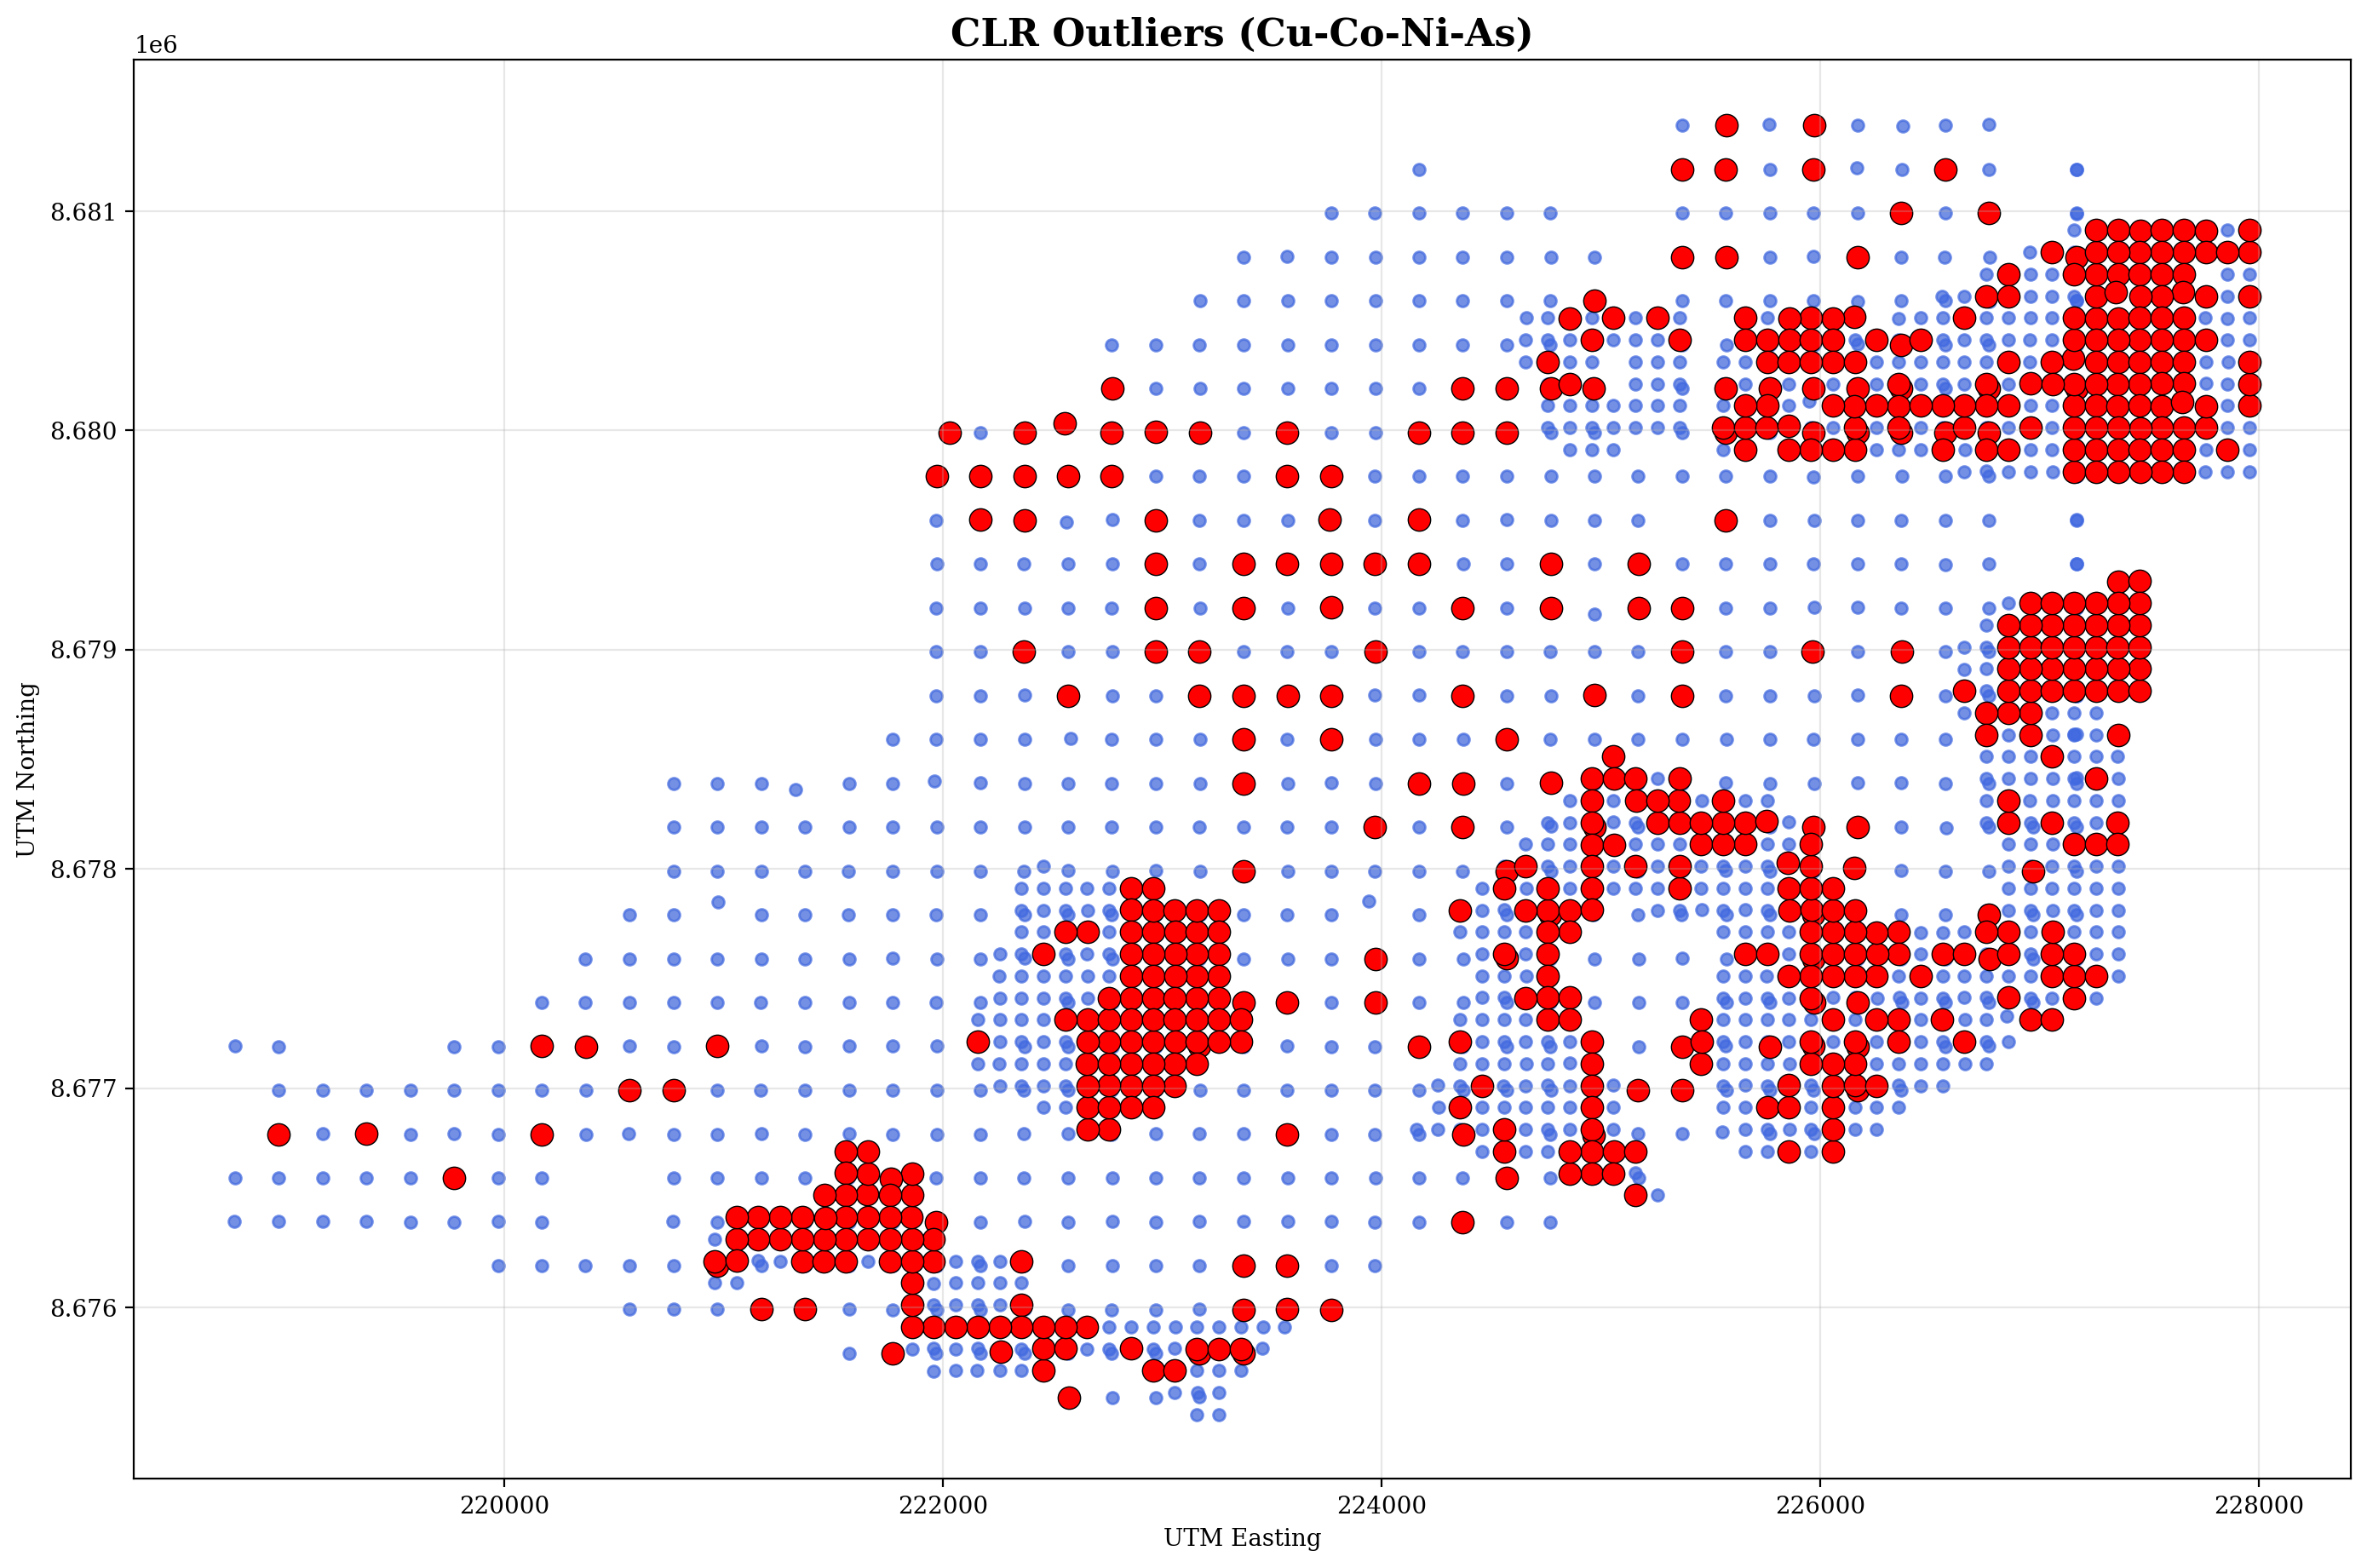

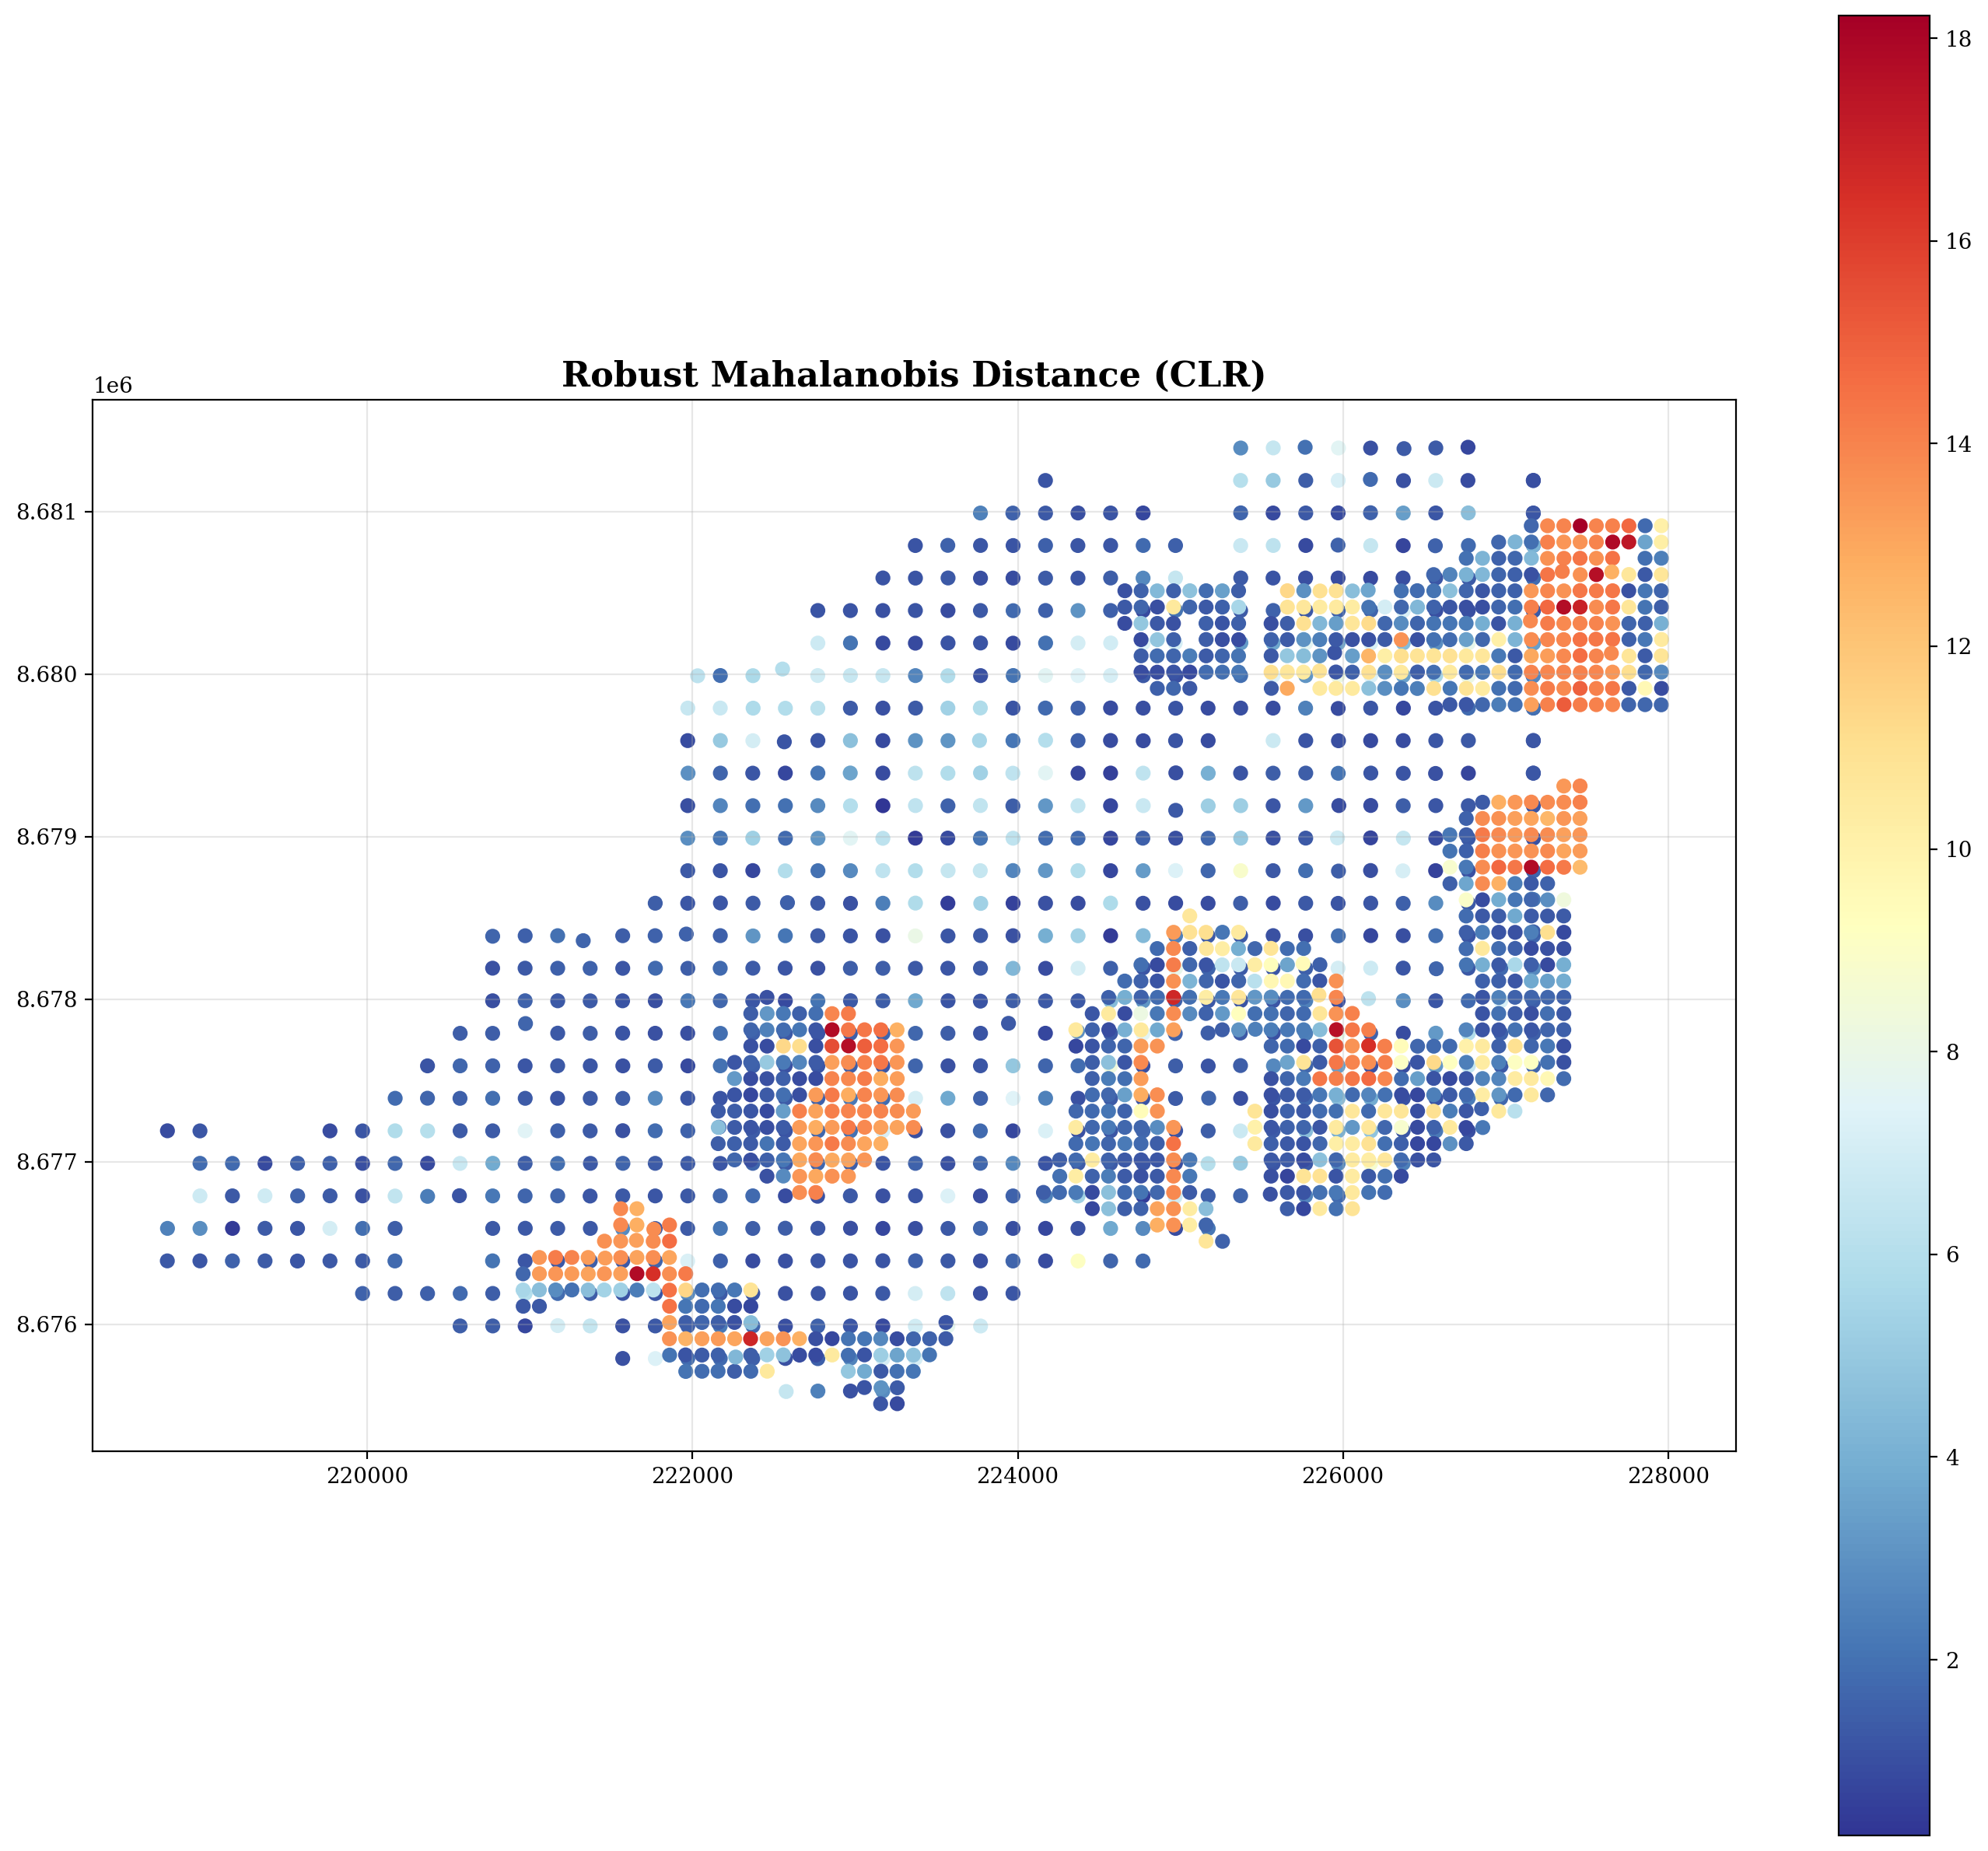


Top anomalies


,X,Y,RMD,Cu(PPM),Co(PPM),Ni(PPM),As(PPM)
1024,227459.212099,8.680911e+06,18.222862,83.370300,7528.549805,8094.040039,41475.101562
1029,227658.700356,8.680812e+06,17.810836,120.033997,4753.319824,9203.750000,68190.398438
869,227158.191313,8.678812e+06,17.786822,107.191002,5061.029785,8891.490234,53025.699219
1600,222858.160693,8.677812e+06,17.760842,62.419399,2342.989990,5753.149902,33082.000000
1219,221658.340248,8.676312e+06,17.749117,95.336601,5607.359863,7650.479980,40676.699219
1048,227358.002729,8.680411e+06,17.664206,50.855701,1492.550049,4962.049805,27593.900391
1602,222959.343160,8.677713e+06,17.657121,76.330002,1015.849976,5519.129883,65338.601562
1038,227558.272639,8.680611e+06,17.646594,106.641998,7125.310059,6173.229980,42165.000000
1591,225959.798911,8.677813e+06,17.554550,69.093498,3374.340088,4878.250000,28219.699219
1028,227757.992296,8.680812e+06,17.353033,70.824997,1922.469971,6695.080078,30233.000000


In [53]:
# =============================================================================
# COMBINED MASTER
# ROBUST CLR OUTLIER MAPPING
# Cu – Co – Ni – As
# FORCED SPATIAL MAPS
# =============================================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point
from skbio.stats.composition import clr
from sklearn.covariance import MinCovDet
import scipy.stats as stats

# =============================================================================
# 1. LOAD DATA
# =============================================================================

df = COMBINED_MASTER.copy()

print(f"Original samples: {len(df):,}")

# =============================================================================
# 2. COORDINATE DETECTION
# =============================================================================

east_candidates = [
    "East",
    "Easting",
    "east_rotate_zero",
    "East_GPX"
]

north_candidates = [
    "North",
    "Northing",
    "north_rotate_zero",
    "North_GPX"
]

east_col = next((c for c in east_candidates if c in df.columns), None)
north_col = next((c for c in north_candidates if c in df.columns), None)

if east_col is None:
    raise ValueError("No Easting column found")

if north_col is None:
    raise ValueError("No Northing column found")

print(f"Using coordinates: {east_col} , {north_col}")

df["X"] = pd.to_numeric(df[east_col], errors="coerce")
df["Y"] = pd.to_numeric(df[north_col], errors="coerce")

df = df.dropna(subset=["X","Y"])

# =============================================================================
# 3. REMOVE BAD COORDINATES
# =============================================================================

df = df[
    (df["X"] > 100000) &
    (df["X"] < 900000) &
    (df["Y"] > 8000000) &
    (df["Y"] < 9000000)
]

print(f"Samples after coordinate cleaning: {len(df):,}")

# =============================================================================
# 4. REMOVE DUPLICATES
# =============================================================================

if "Sample_ID" in df.columns:
    df = df.drop_duplicates(subset="Sample_ID")

df = df.drop_duplicates(subset=["X","Y"])

print(f"Samples after duplicate removal: {len(df):,}")

# =============================================================================
# 5. ELEMENTS
# =============================================================================

elements = [
    "Cu(PPM)",
    "Co(PPM)",
    "Ni(PPM)",
    "As(PPM)"
]

elements = [e for e in elements if e in df.columns]

print("Elements used:")
print(elements)

if len(elements) < 2:
    raise ValueError("Not enough pathfinder elements found")

# =============================================================================
# 6. ZERO REPLACEMENT
# =============================================================================

def mult_replace(series):

    vals = pd.to_numeric(
        series,
        errors="coerce"
    ).fillna(0).values.astype(float)

    positive = vals[vals > 0]

    if len(positive) == 0:
        raise ValueError(f"{series.name} contains only zeros")

    delta = positive.min() * (2/3)

    vals[vals == 0] = delta

    return vals

comp_data = pd.DataFrame()

for col in elements:
    comp_data[col] = mult_replace(df[col])

# =============================================================================
# 7. CLR
# =============================================================================

clr_matrix = clr(comp_data.values)

clr_df = pd.DataFrame(
    clr_matrix,
    columns=[f"CLR_{c}" for c in elements]
)

# =============================================================================
# 8. ROBUST MAHALANOBIS
# =============================================================================

X = clr_df.values

mcd = MinCovDet(
    support_fraction=0.75,
    random_state=42
)

mcd.fit(X)

rmd = np.sqrt(
    mcd.mahalanobis(X)
)

threshold = np.sqrt(
    stats.chi2.ppf(
        0.975,
        df=X.shape[1]
    )
)

df["RMD"] = rmd

df["Outlier"] = rmd > threshold

print(f"\nOutliers detected: {df['Outlier'].sum():,}")
print(f"Threshold: {threshold:.2f}")

# =============================================================================
# 9. CREATE GEODATAFRAME
# =============================================================================

geometry = [
    Point(xy)
    for xy in zip(df["X"], df["Y"])
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:32735"
)

print(gdf.crs)

# =============================================================================
# 10. OUTLIER MAP
# =============================================================================

fig, ax = plt.subplots(
    figsize=(14,12)
)

# background

gdf.plot(
    ax=ax,
    color="lightgrey",
    markersize=20,
    alpha=0.4
)

# inliers

gdf[gdf["Outlier"] == False].plot(
    ax=ax,
    color="royalblue",
    markersize=25,
    alpha=0.7
)

# outliers

gdf[gdf["Outlier"]].plot(
    ax=ax,
    color="red",
    markersize=90,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title(
    "CLR Outliers (Cu-Co-Ni-As)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("UTM Easting")
ax.set_ylabel("UTM Northing")

ax.grid(
    True,
    alpha=0.3
)

ax.set_aspect("equal")

plt.tight_layout()

plt.show()

# =============================================================================
# 11. CONTINUOUS ANOMALY MAP
# =============================================================================

fig, ax = plt.subplots(
    figsize=(14,12)
)

gdf.plot(
    ax=ax,
    column="RMD",
    cmap="RdYlBu_r",
    legend=True,
    markersize=35
)

ax.set_title(
    "Robust Mahalanobis Distance (CLR)",
    fontsize=16,
    fontweight="bold"
)

ax.set_aspect("equal")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# =============================================================================
# 12. SAVE RESULTS
# =============================================================================

OUTLIERS = gdf[gdf["Outlier"]].copy()

print("\nTop anomalies")

display(
    OUTLIERS[
        ["X","Y","RMD"] + elements
    ]
    .sort_values(
        "RMD",
        ascending=False
    )
    .head(20)
)